# Notebook 7: RandomForestClassifier (Optuna) + BaggingClassifier Ensemble
---
Extract latent deep features from HybridFashionModel and train two ensemble classifiers:
1. **RandomForestClassifier** — tuned via Optuna hyperparameter search
2. **BaggingClassifier** — a bootstrap aggregating ensemble using DecisionTree base estimators

## Step 1: Feature Extraction Setup

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path("..").resolve()))

In [2]:
from scripts.data_utils import O4UHybridDataset, collate_fn

In [3]:
# ============================================
# Step 1: Setup & Data Loaders
# ============================================
import json
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm
from torch.utils.data import DataLoader
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import warnings
warnings.filterwarnings("ignore")

from scripts.models import HybridFashionModel, FeatureExtractor
from scripts.config import DATA_PROCESSED_DIR, FEATURES_DIR as _FEATURES_DIR, SAVED_MODELS_DIR

device = torch.device("mps" if torch.backends.mps.is_available() else "cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

# Load phys_feature_cols from saved artifact — must match the trained model exactly
with open(SAVED_MODELS_DIR / "phys_feature_cols.json") as f:
    phys_feature_cols = json.load(f)
phys_dim_input = len(phys_feature_cols)
print(f"Physical feature dim: {phys_dim_input}")

FEATURES_DIR = str(_FEATURES_DIR)
df_train = pd.read_json(DATA_PROCESSED_DIR / "train_imputed_manifest.json")
df_val   = pd.read_json(DATA_PROCESSED_DIR / "val_imputed_manifest.json")

train_loader = DataLoader(O4UHybridDataset(df_train, FEATURES_DIR, phys_feature_cols),
                          batch_size=32, shuffle=False, collate_fn=collate_fn, num_workers=0)
val_loader   = DataLoader(O4UHybridDataset(df_val,   FEATURES_DIR, phys_feature_cols),
                          batch_size=32, shuffle=False, collate_fn=collate_fn, num_workers=0)
print("DataLoaders ready.")

Device: mps
Physical feature dim: 99
 Checking/Caching 10080 visual features...
 Checking/Caching 2520 visual features...
DataLoaders ready.


In [4]:
# ============================================
# Load Model & Extract Features
# ============================================
model = HybridFashionModel(phys_input_dim=phys_dim_input).to(device)
checkpoint = torch.load(str(SAVED_MODELS_DIR / "best_hybrid_model.pth"), map_location=device, weights_only=True)
if isinstance(checkpoint, dict) and "model_state_dict" in checkpoint:
    model.load_state_dict(checkpoint["model_state_dict"])
else:
    model.load_state_dict(checkpoint)
model.eval()

extractor = FeatureExtractor(model).to(device)
extractor.eval()


def extract_features(loader, desc):
    features_list, labels_list = [], []
    with torch.inference_mode():
        # collate_fn returns: visual_padded, visual_mask, phys_vecs, reg_labels, bin_labels
        for visual_feat, visual_mask, phys_vecs, reg_labels, bin_labels in tqdm(loader, desc=desc):
            visual_feat = visual_feat.to(device)
            visual_mask = visual_mask.to(device)
            phys_vecs   = phys_vecs.to(device)
            fused = extractor(visual_feat, visual_mask, phys_vecs)
            features_list.append(fused.cpu().numpy())
            labels_list.append(bin_labels.numpy())
    return np.vstack(features_list), np.concatenate(labels_list)


X_train, y_train = extract_features(train_loader, "Train")
X_val,   y_val   = extract_features(val_loader,   "Val")
print(f"X_train: {X_train.shape}, X_val: {X_val.shape}")

del model, extractor
import gc; gc.collect()

Train:   0%|          | 0/315 [00:00<?, ?it/s]

Val:   0%|          | 0/79 [00:00<?, ?it/s]

X_train: (10080, 256), X_val: (2520, 256)


48

## Step 2: BaggingClassifier
---
**BaggingClassifier** trains multiple `DecisionTreeClassifier` base estimators on random subsets of the training data and averages their predictions.

- `estimator=DecisionTreeClassifier(max_depth=5)`: shallow trees to limit complexity
- `n_estimators=50`: 50 bootstrap replicates
- `max_samples=0.8`: each tree trained on 80% of data (with replacement)

Training BaggingClassifier (50 estimators, DecisionTree base)...
BaggingClassifier Results:
  Accuracy : 90.60%
  F1-Score : 0.9226


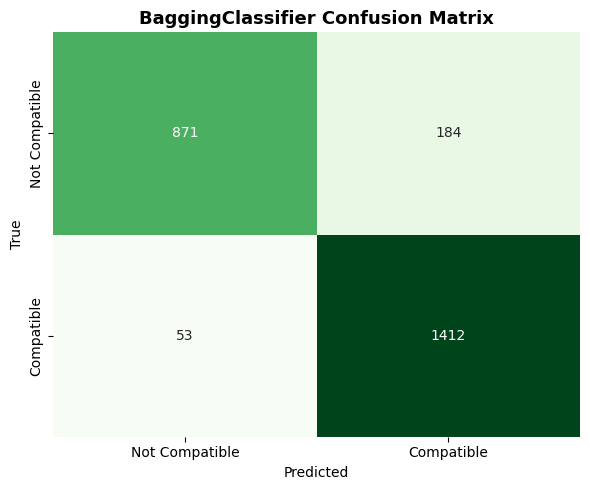

In [5]:
# ============================================
# BaggingClassifier
# ============================================
print("Training BaggingClassifier (50 estimators, DecisionTree base)...")

bagging_model = BaggingClassifier(
    estimator=DecisionTreeClassifier(max_depth=5, random_state=42),
    n_estimators=50,
    max_samples=0.8,
    max_features=1.0,
    n_jobs=1,
    random_state=42,
)
bagging_model.fit(X_train, y_train)

y_pred_bagging = bagging_model.predict(X_val)
print(f"BaggingClassifier Results:")
print(f"  Accuracy : {accuracy_score(y_val, y_pred_bagging)*100:.2f}%")
print(f"  F1-Score : {f1_score(y_val, y_pred_bagging):.4f}")

cm = confusion_matrix(y_val, y_pred_bagging)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Greens", cbar=False,
            xticklabels=["Not Compatible", "Compatible"],
            yticklabels=["Not Compatible", "Compatible"])
plt.title("BaggingClassifier Confusion Matrix", fontsize=13, fontweight="bold")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()

## Step 3: RandomForestClassifier via Optuna
---
Optuna tunes hyperparameters via 3-fold CV on the training set only (no val leakage).

### Search Space Rationale

| Hyperparameter | Range | Rationale |
|---|---|---|
| `n_estimators` | [50, 500] | Project-wide standard. 50 = minimum for stable variance reduction; 500 = diminishing returns cap. |
| `max_depth` | [3, 15] | Prevents underfitting (>=3) and overfitting (<=15) on ~10k samples. |
| `max_samples` | [0.5, 1.0] | Bootstrap fraction; below 0.5 produces noisy trees. |
| `max_features` | {sqrt, log2} | Standard sklearn heuristics for classification. |

In [6]:
# ============================================
# RandomForestClassifier via Optuna
# ============================================
import optuna
from sklearn.model_selection import cross_val_score
from sklearn.metrics import roc_curve

print("Running Optuna for RandomForestClassifier (30 trials, 3-fold CV on train)...")
optuna.logging.set_verbosity(optuna.logging.WARNING)


def objective_rf(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 50, 500),
        "max_depth":    trial.suggest_int("max_depth", 3, 15),
        "max_samples":  trial.suggest_float("max_samples", 0.5, 1.0),
        "max_features": trial.suggest_categorical("max_features", ["sqrt", "log2"]),
        "random_state": 42,
        "n_jobs": 1,
    }
    clf = RandomForestClassifier(**params)
    scores = cross_val_score(clf, X_train, y_train, cv=3, scoring="f1", n_jobs=1)
    return scores.mean()


study = optuna.create_study(direction="maximize")
study.optimize(objective_rf, n_trials=30, show_progress_bar=True)

print(f"\nBest RandomForest params: {study.best_params}")
print(f"Best CV F1: {study.best_value:.4f}")

# Train best model
best_params = {**study.best_params, "random_state": 42, "n_jobs": 1}
final_rf_model = RandomForestClassifier(**best_params)
final_rf_model.fit(X_train, y_train)

y_probs = final_rf_model.predict_proba(X_val)[:, 1]
fpr, tpr, thresholds = roc_curve(y_val, y_probs)
opt_thr = thresholds[np.argmax(tpr - fpr)]

print(f"\nOptimal Threshold (Youden's J): {opt_thr:.4f}")

y_pred_opt = (y_probs >= opt_thr).astype(int)
print(f"\nRandomForestClassifier Results (Optuna-tuned, Youden threshold):")
print(f"  Accuracy  : {accuracy_score(y_val, y_pred_opt)*100:.2f}%")
print(f"  Precision : {precision_score(y_val, y_pred_opt, zero_division=0)*100:.2f}%")
print(f"  Recall    : {recall_score(y_val, y_pred_opt, zero_division=0)*100:.2f}%")
print(f"  F1-Score  : {f1_score(y_val, y_pred_opt, zero_division=0):.4f}")

import json as _json
with open(str(SAVED_MODELS_DIR / "nb05_best_params.json"), "w") as _f:
    _json.dump(study.best_params, _f, indent=2)
print("Best params saved to saved_models/nb05_best_params.json")

Running Optuna for RandomForestClassifier (30 trials, 3-fold CV on train)...


  0%|          | 0/30 [00:00<?, ?it/s]


Best RandomForest params: {'n_estimators': 500, 'max_depth': 6, 'max_samples': 0.5812531606051744, 'max_features': 'log2'}
Best CV F1: 0.9383

Optimal Threshold (Youden's J): 0.3616

RandomForestClassifier Results (Optuna-tuned, Youden threshold):
  Accuracy  : 90.79%
  Precision : 88.08%
  Recall    : 97.34%
  F1-Score  : 0.9248
Best params saved to saved_models/nb05_best_params.json
